In [1]:
print("hello world")

hello world


In [2]:
# Local VS Code Setup (Python 3.10)
# This cell replaces the Google Colab setup

import os
import sys

# Get the directory where this notebook is located
NOTEBOOK_DIR = os.getcwd()

# Add the assignment directory to Python path if not already there
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Python version: {sys.version}")

# Verify the cs231n module is accessible
assert os.path.exists("cs231n"), "cs231n folder not found. Make sure you are in the assignment1 directory."
print("Setup complete! cs231n module is accessible.")

Working directory: c:\keyLabLocal_D\cs231n\assignments\assignment1
Python version: 3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]
Setup complete! cs231n module is accessible.


# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [3]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [4]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV (hue, saturation, value)
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [5]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train Softmax classifier on features
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

In [6]:
num_dev = 500
num_training = 49000

In [7]:
mask_dummy = np.random.choice(100, 5, replace=False)
print(mask_dummy)

[23 97 38 50 36]


In [8]:
mask = np.random.choice(num_training, num_dev, replace=False)

In [9]:
X_dev = X_train_feats[mask]

In [10]:
y_dev = y_train[mask]

In [11]:




X_val = X_val_feats

In [13]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import Softmax
import time

# learning_rates = [1e-7, 1e-6]
# regularization_strengths = [5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################



# Provided as a reference. You may or may not want to change these hyperparameters
best_learning_rate = None
best_regularization_strength = None

# learning_rates = range([1e-9, 1e-2])
# regularization_strengths = range([1e-6, 1e6])
# Generate hyperparameter values on logarithmic scale
learning_rates = np.logspace(-9, -2, num=8)  # [1e-9, 1e-8, ..., 1e-2]
regularization_strengths = np.logspace(-6, 6, num=7)  # [1e-6, 1e-4, ..., 1e6]

for learning_rate in learning_rates:
  for regularization_strength in regularization_strengths:

    softmax = Softmax()
    tic = time.time()
    loss_hist = softmax.train(X_dev, y_dev, learning_rate=learning_rate, reg=regularization_strength,
                          num_iters=100, verbose=False)

    y_train_pred = softmax.predict(X_dev)
    y_val_pred = softmax.predict(X_val)

    training_accuracy = np.mean(y_dev == y_train_pred)
    validation_accuracy = np.mean(y_val == y_val_pred)
    # results[(learning_rate,regularization_strength)] = [training_accuracy, validation_accuracy]
    results[(learning_rate, regularization_strength)] = (training_accuracy, validation_accuracy)


    if validation_accuracy > best_val:
      best_val = validation_accuracy
      best_softmax = softmax
      best_learning_rate = learning_rate
      best_regularization_strength = regularization_strength



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('best learning rate: %e' % best_learning_rate)
print('best regularization strength: %e' % best_regularization_strength)



# # Print out results.
# for lr, reg in sorted(results):
#     train_accuracy, val_accuracy = results[(lr, reg)]
#     print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
#                 lr, reg, train_accuracy, val_accuracy))

# print('best validation accuracy achieved: %f' % best_val)

c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\softmax.py:155: RuntimeWarning: divide by zero encountered in log
  log_probs = np.log(probs)  # (N, C)
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\softmax.py:186: RuntimeWarning: overflow encountered in scalar multiply
  loss = data_loss + reg * np.sum(W * W)
c:\Users\zpa18\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\softmax.py:186: RuntimeWarning: overflow encountered in multiply
  loss = data_loss + reg * np.sum(W * W)
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\softmax.py:214: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\softmax.py:131: RuntimeWarning: invalid value e

lr 1.000000e-09 reg 1.000000e-06 train accuracy: 0.116000 val accuracy: 0.122000
lr 1.000000e-09 reg 1.000000e-04 train accuracy: 0.066000 val accuracy: 0.070000
lr 1.000000e-09 reg 1.000000e-02 train accuracy: 0.086000 val accuracy: 0.112000
lr 1.000000e-09 reg 1.000000e+00 train accuracy: 0.094000 val accuracy: 0.101000
lr 1.000000e-09 reg 1.000000e+02 train accuracy: 0.082000 val accuracy: 0.110000
lr 1.000000e-09 reg 1.000000e+04 train accuracy: 0.098000 val accuracy: 0.119000
lr 1.000000e-09 reg 1.000000e+06 train accuracy: 0.064000 val accuracy: 0.087000
lr 1.000000e-08 reg 1.000000e-06 train accuracy: 0.136000 val accuracy: 0.100000
lr 1.000000e-08 reg 1.000000e-04 train accuracy: 0.050000 val accuracy: 0.077000
lr 1.000000e-08 reg 1.000000e-02 train accuracy: 0.102000 val accuracy: 0.097000
lr 1.000000e-08 reg 1.000000e+00 train accuracy: 0.104000 val accuracy: 0.088000
lr 1.000000e-08 reg 1.000000e+02 train accuracy: 0.056000 val accuracy: 0.082000
lr 1.000000e-08 reg 1.000000

best validation accuracy achieved during cross-validation: 0.395000
best learning rate: 1.000000e-02
best regularization strength: 1.000000e-06

lr 1.000000e+03 reg 1.000000e-05 train accuracy: 0.812000 val accuracy: 0.317000
best validation accuracy achieved during cross-validation: 0.412000
best learning rate: 5.179475e-02
best regularization strength: 4.641589e-09

In [15]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import Softmax
import time

# learning_rates = [1e-7, 1e-6]
# regularization_strengths = [5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################



# Provided as a reference. You may or may not want to change these hyperparameters
best_learning_rate = None
best_regularization_strength = None

# learning_rates = range([1e-9, 1e-2])
# regularization_strengths = range([1e-6, 1e6])
# Generate hyperparameter values on logarithmic scale
learning_rates = np.logspace(-6, 6, num=20)  # [1e-9, 1e-8, ..., 1e-2]
regularization_strengths = np.logspace(-14, -5, num=20)  # [1e-6, 1e-4, ..., 1e6]

for learning_rate in learning_rates:
  for regularization_strength in regularization_strengths:

    softmax = Softmax()
    tic = time.time()
    loss_hist = softmax.train(X_dev, y_dev, learning_rate=learning_rate, reg=regularization_strength,
                          num_iters=100, verbose=False)

    y_train_pred = softmax.predict(X_dev)
    y_val_pred = softmax.predict(X_val)

    training_accuracy = np.mean(y_dev == y_train_pred)
    validation_accuracy = np.mean(y_val == y_val_pred)
    # results[(learning_rate,regularization_strength)] = [training_accuracy, validation_accuracy]
    results[(learning_rate, regularization_strength)] = (training_accuracy, validation_accuracy)


    if validation_accuracy > best_val:
      best_val = validation_accuracy
      best_softmax = softmax
      best_learning_rate = learning_rate
      best_regularization_strength = regularization_strength



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('best learning rate: %e' % best_learning_rate)
print('best regularization strength: %e' % best_regularization_strength)



# # Print out results.
# for lr, reg in sorted(results):
#     train_accuracy, val_accuracy = results[(lr, reg)]
#     print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
#                 lr, reg, train_accuracy, val_accuracy))

# print('best validation accuracy achieved: %f' % best_val)

lr 1.000000e-06 reg 1.000000e-14 train accuracy: 0.120000 val accuracy: 0.087000
lr 1.000000e-06 reg 2.976351e-14 train accuracy: 0.078000 val accuracy: 0.098000
lr 1.000000e-06 reg 8.858668e-14 train accuracy: 0.118000 val accuracy: 0.126000
lr 1.000000e-06 reg 2.636651e-13 train accuracy: 0.088000 val accuracy: 0.095000
lr 1.000000e-06 reg 7.847600e-13 train accuracy: 0.098000 val accuracy: 0.097000
lr 1.000000e-06 reg 2.335721e-12 train accuracy: 0.106000 val accuracy: 0.111000
lr 1.000000e-06 reg 6.951928e-12 train accuracy: 0.086000 val accuracy: 0.106000
lr 1.000000e-06 reg 2.069138e-11 train accuracy: 0.098000 val accuracy: 0.098000
lr 1.000000e-06 reg 6.158482e-11 train accuracy: 0.120000 val accuracy: 0.112000
lr 1.000000e-06 reg 1.832981e-10 train accuracy: 0.090000 val accuracy: 0.101000
lr 1.000000e-06 reg 5.455595e-10 train accuracy: 0.142000 val accuracy: 0.122000
lr 1.000000e-06 reg 1.623777e-09 train accuracy: 0.102000 val accuracy: 0.089000
lr 1.000000e-06 reg 4.832930

In [17]:
#  best learning rate: 5.179475e-02
# best regularization strength: 4.641589e-09
# Train final model with best hyperparameters on full training set
best_learning_rate =5.179475e-02
best_regularization_strength = 4.641589e-09
best_softmax = Softmax()
loss_hist = best_softmax.train(X_train_feats, y_train, best_learning_rate, best_regularization_strength,
                      num_iters=1500, verbose=True)

iteration 0 / 1500: loss 2.302778
iteration 100 / 1500: loss 1.557822
iteration 200 / 1500: loss 1.323076
iteration 300 / 1500: loss 1.210800
iteration 400 / 1500: loss 1.429404
iteration 500 / 1500: loss 1.421021
iteration 600 / 1500: loss 1.410174
iteration 700 / 1500: loss 1.404253
iteration 800 / 1500: loss 1.298806
iteration 900 / 1500: loss 1.379395
iteration 1000 / 1500: loss 1.277808
iteration 1100 / 1500: loss 1.380003
iteration 1200 / 1500: loss 1.412858
iteration 1300 / 1500: loss 1.432654
iteration 1400 / 1500: loss 1.311607


In [12]:
from cs231n.classifiers.linear_classifier import Softmax

best_softmax = Softmax()
best_softmax.load("best_softmax_features.npy")

best_softmax_features.npy loaded.


True

In [13]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.513


In [19]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


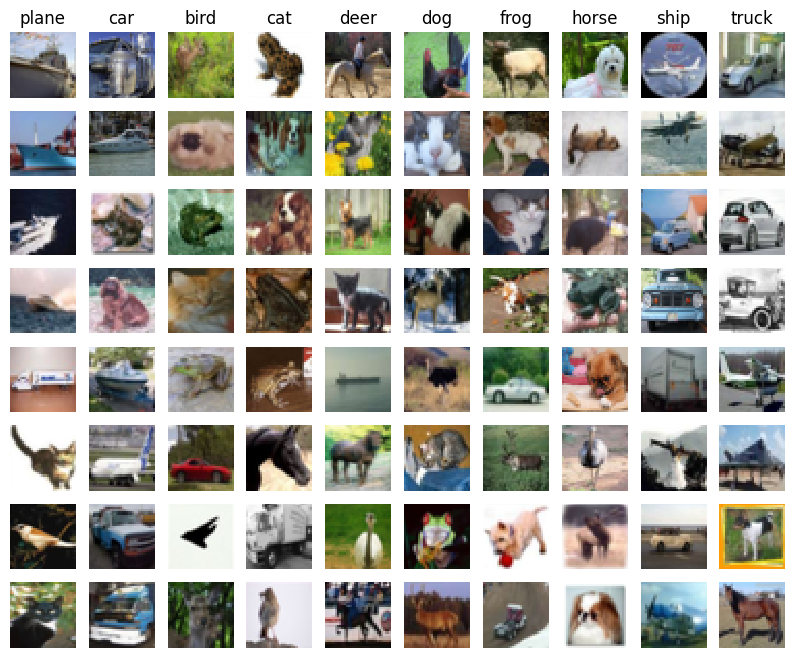

In [20]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer: }$
yes. it is close. shows the margin, rough shape, and the most probable color combinations.





## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [14]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 170)
(49000, 169)


In [16]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver
import time

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}

# net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################


results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
# best_softmax = None # The Softmax object that achieved the highest validation rate.


# Provided as a reference. You may or may not want to change these hyperparameters
best_hidden_layer_size = None
best_learning_rate = None
best_training_epochs = None
best_regularization_strength = None

# learning_rates = range([1e-9, 1e-2])
# regularization_strengths = range([1e-6, 1e6])
# Generate hyperparameter values on logarithmic scale
learning_rates = np.logspace(-4, -2, num=4)  # [1e-9, 1e-8, ..., 1e-2]
regularization_strengths = np.logspace(-6, 6, num=4)  # [1e-6, 1e-4, ..., 1e6]

for learning_rate in learning_rates:
  for regularization_strength in regularization_strengths:
    model = TwoLayerNet(input_dim, hidden_dim, num_classes, reg=regularization_strength)

    tic = time.time()
    solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': learning_rate,
                    },
                    lr_decay=0.95,
                    num_epochs=5, batch_size=200,
                    print_every=100)
    solver.train()


    # plt.plot(solver.loss_history, 'o')
    # plt.xlabel('Iteration')

    # plt.subplot(2, 1, 2)
    # plt.title('Accuracy')
    # plt.plot(solver.train_acc_history, '-o', label='train')
    # plt.plot(solver.val_acc_history, '-o', label='val')

    # y_train_pred = solver.predict(data['X_train'])
    # y_val_pred = solver.predict(data['X_val'])



    # training_accuracy = np.mean(data['y_train'] == y_train_pred)
    # validation_accuracy = np.mean(data['y_val'] == y_val_pred)
    training_accuracy = solver.check_accuracy(data['X_train'], data['y_train'], num_samples=None, batch_size=200)
    validation_accuracy = solver.check_accuracy(data['X_val'], data['y_val'], num_samples=None, batch_size=200)
    # results[(learning_rate,regularization_strength)] = [training_accuracy, validation_accuracy]
    results[(learning_rate, regularization_strength)] = (training_accuracy, validation_accuracy)


    if validation_accuracy > best_val:
      best_val = validation_accuracy
      best_model = model
      best_learning_rate = learning_rate
      best_regularization_strength = regularization_strength



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('best learning rate: %e' % best_learning_rate)
print('best regularization strength: %e' % best_regularization_strength)



(Iteration 1 / 1225) loss: 2.302571
(Epoch 0 / 5) train acc: 0.099000; val_acc: 0.088000
(Iteration 101 / 1225) loss: 2.302583
(Iteration 201 / 1225) loss: 2.302580
(Epoch 1 / 5) train acc: 0.094000; val_acc: 0.104000
(Iteration 301 / 1225) loss: 2.302598
(Iteration 401 / 1225) loss: 2.302555
(Epoch 2 / 5) train acc: 0.096000; val_acc: 0.102000
(Iteration 501 / 1225) loss: 2.302616
(Iteration 601 / 1225) loss: 2.302557
(Iteration 701 / 1225) loss: 2.302580
(Epoch 3 / 5) train acc: 0.126000; val_acc: 0.103000
(Iteration 801 / 1225) loss: 2.302583
(Iteration 901 / 1225) loss: 2.302547
(Epoch 4 / 5) train acc: 0.123000; val_acc: 0.104000
(Iteration 1001 / 1225) loss: 2.302566
(Iteration 1101 / 1225) loss: 2.302576
(Iteration 1201 / 1225) loss: 2.302576
(Epoch 5 / 5) train acc: 0.118000; val_acc: 0.112000
(Iteration 1 / 1225) loss: 2.303027
(Epoch 0 / 5) train acc: 0.085000; val_acc: 0.095000
(Iteration 101 / 1225) loss: 2.303032
(Iteration 201 / 1225) loss: 2.303032
(Epoch 1 / 5) train ac

c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\layers.py:805: RuntimeWarning: divide by zero encountered in log
  log_probs = np.log(probs)  # (N, C)
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\classifiers\fc_net.py:167: RuntimeWarning: overflow encountered in scalar multiply
  reg_loss = 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2))
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\layers.py:38: RuntimeWarning: overflow encountered in matmul
  out = x_reshaped @ w + b
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\layers.py:782: RuntimeWarning: overflow encountered in subtract
  scores = scores - np.max(scores, axis=1, keepdims=True) # missed this line, lead to results dx error 0.3333
c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\layers.py:782: RuntimeWarning: invalid value encountered in subtract
  scores = scores - np.max(scores, axis=1, keepdims=True) # missed this line, lead to results dx error 0.3333
c:\Users\zpa18\AppData\Local\Program

(Iteration 101 / 1225) loss: nan
(Iteration 201 / 1225) loss: nan
(Epoch 1 / 5) train acc: 0.126000; val_acc: 0.087000
(Iteration 301 / 1225) loss: nan
(Iteration 401 / 1225) loss: nan
(Epoch 2 / 5) train acc: 0.097000; val_acc: 0.087000
(Iteration 501 / 1225) loss: nan
(Iteration 601 / 1225) loss: nan
(Iteration 701 / 1225) loss: nan
(Epoch 3 / 5) train acc: 0.095000; val_acc: 0.087000
(Iteration 801 / 1225) loss: nan
(Iteration 901 / 1225) loss: nan
(Epoch 4 / 5) train acc: 0.099000; val_acc: 0.087000
(Iteration 1001 / 1225) loss: nan
(Iteration 1101 / 1225) loss: nan
(Iteration 1201 / 1225) loss: nan
(Epoch 5 / 5) train acc: 0.093000; val_acc: 0.087000
(Iteration 1 / 1225) loss: 2.302567
(Epoch 0 / 5) train acc: 0.090000; val_acc: 0.115000
(Iteration 101 / 1225) loss: 2.302580
(Iteration 201 / 1225) loss: 2.302577
(Epoch 1 / 5) train acc: 0.112000; val_acc: 0.133000
(Iteration 301 / 1225) loss: 2.302560
(Iteration 401 / 1225) loss: 2.302543
(Epoch 2 / 5) train acc: 0.135000; val_acc

c:\keyLabLocal_D\cs231n\assignments\assignment1\cs231n\layers.py:38: RuntimeWarning: invalid value encountered in matmul
  out = x_reshaped @ w + b


(Iteration 101 / 1225) loss: nan
(Iteration 201 / 1225) loss: nan
(Epoch 1 / 5) train acc: 0.080000; val_acc: 0.087000
(Iteration 301 / 1225) loss: nan
(Iteration 401 / 1225) loss: nan
(Epoch 2 / 5) train acc: 0.102000; val_acc: 0.087000
(Iteration 501 / 1225) loss: nan
(Iteration 601 / 1225) loss: nan
(Iteration 701 / 1225) loss: nan
(Epoch 3 / 5) train acc: 0.096000; val_acc: 0.087000
(Iteration 801 / 1225) loss: nan
(Iteration 901 / 1225) loss: nan
(Epoch 4 / 5) train acc: 0.110000; val_acc: 0.087000
(Iteration 1001 / 1225) loss: nan
(Iteration 1101 / 1225) loss: nan
(Iteration 1201 / 1225) loss: nan
(Epoch 5 / 5) train acc: 0.097000; val_acc: 0.087000
(Iteration 1 / 1225) loss: 2.302596
(Epoch 0 / 5) train acc: 0.106000; val_acc: 0.124000
(Iteration 101 / 1225) loss: 2.302546
(Iteration 201 / 1225) loss: 2.302512
(Epoch 1 / 5) train acc: 0.102000; val_acc: 0.078000
(Iteration 301 / 1225) loss: 2.302436
(Iteration 401 / 1225) loss: 2.302280
(Epoch 2 / 5) train acc: 0.099000; val_acc

best learning rate: 1.000000e-02
best regularization strength: 1.000000e-06

In [17]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver
import time

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}

# net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################


results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
# best_softmax = None # The Softmax object that achieved the highest validation rate.


# Provided as a reference. You may or may not want to change these hyperparameters
best_hidden_layer_size = None
best_learning_rate = None
best_training_epochs = None
best_regularization_strength = None

# learning_rates = range([1e-9, 1e-2])
# regularization_strengths = range([1e-6, 1e6])
# Generate hyperparameter values on logarithmic scale
learning_rates = np.logspace(-2, 2, num=4)  # [1e-9, 1e-8, ..., 1e-2]
regularization_strengths = np.logspace(-12, -6, num=4)  # [1e-6, 1e-4, ..., 1e6]

for learning_rate in learning_rates:
  for regularization_strength in regularization_strengths:
    model = TwoLayerNet(input_dim, hidden_dim, num_classes, reg=regularization_strength)

    tic = time.time()
    solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': learning_rate,
                    },
                    lr_decay=0.95,
                    num_epochs=5, batch_size=200,
                    print_every=100)
    solver.train()


    # plt.plot(solver.loss_history, 'o')
    # plt.xlabel('Iteration')

    # plt.subplot(2, 1, 2)
    # plt.title('Accuracy')
    # plt.plot(solver.train_acc_history, '-o', label='train')
    # plt.plot(solver.val_acc_history, '-o', label='val')

    # y_train_pred = solver.predict(data['X_train'])
    # y_val_pred = solver.predict(data['X_val'])



    # training_accuracy = np.mean(data['y_train'] == y_train_pred)
    # validation_accuracy = np.mean(data['y_val'] == y_val_pred)
    training_accuracy = solver.check_accuracy(data['X_train'], data['y_train'], num_samples=None, batch_size=200)
    validation_accuracy = solver.check_accuracy(data['X_val'], data['y_val'], num_samples=None, batch_size=200)
    # results[(learning_rate,regularization_strength)] = [training_accuracy, validation_accuracy]
    results[(learning_rate, regularization_strength)] = (training_accuracy, validation_accuracy)


    if validation_accuracy > best_val:
      best_val = validation_accuracy
      best_model = model
      best_learning_rate = learning_rate
      best_regularization_strength = regularization_strength



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('best learning rate: %e' % best_learning_rate)
print('best regularization strength: %e' % best_regularization_strength)



(Iteration 1 / 1225) loss: 2.302586
(Epoch 0 / 5) train acc: 0.119000; val_acc: 0.083000
(Iteration 101 / 1225) loss: 2.302615
(Iteration 201 / 1225) loss: 2.302294
(Epoch 1 / 5) train acc: 0.133000; val_acc: 0.090000
(Iteration 301 / 1225) loss: 2.301396
(Iteration 401 / 1225) loss: 2.300948
(Epoch 2 / 5) train acc: 0.269000; val_acc: 0.251000
(Iteration 501 / 1225) loss: 2.299373
(Iteration 601 / 1225) loss: 2.297786
(Iteration 701 / 1225) loss: 2.294891
(Epoch 3 / 5) train acc: 0.280000; val_acc: 0.282000
(Iteration 801 / 1225) loss: 2.284784
(Iteration 901 / 1225) loss: 2.267114
(Epoch 4 / 5) train acc: 0.282000; val_acc: 0.287000
(Iteration 1001 / 1225) loss: 2.252038
(Iteration 1101 / 1225) loss: 2.231580
(Iteration 1201 / 1225) loss: 2.167955
(Epoch 5 / 5) train acc: 0.270000; val_acc: 0.270000
(Iteration 1 / 1225) loss: 2.302595
(Epoch 0 / 5) train acc: 0.108000; val_acc: 0.107000
(Iteration 101 / 1225) loss: 2.302279
(Iteration 201 / 1225) loss: 2.301883
(Epoch 1 / 5) train ac

In [19]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

best_net = best_model

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.562


In [20]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
